# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Patrick Lee

**Date:** 9/2/26

After coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total missings:
 0 

df.shape:
(30478, 14) 

df.dtypes:
Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                           int64
Review Scores Rating          float64
Price_nan                        bool
dtype: object 



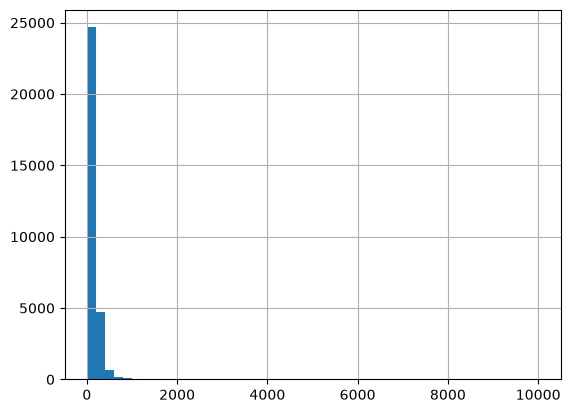

In [1]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('data/airbnb_hw.csv', low_memory=False)



df.head()

df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Price_nan'] = df['Price'].isnull()

print('After coercion:\n', df['Price'].describe(), '\n')
df['Price'].hist(bins=50)
print('Total missings:\n', sum(df['Price_nan']), '\n')


print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('data/mn_police_use_of_force.csv', low_memory=False)



df.head()


var = 'subject_injury'
print(df[var].unique(), '\n')
df[var] = df[var].replace('', np.nan) # Replace missing values with NaN
print(df[var].value_counts(), '\n')

df['subject_injury_nan'] = df['subject_injury'].isnull()
print('Total missings:\n', sum(df['subject_injury_nan']), '\n') # Prints total missing values
proportion_missing = sum(df['subject_injury_nan']) / len(df['subject_injury'])
print('Proportion missing:\n', proportion_missing) # Prints proportional missing values
# pd.crosstab(df['subject_injury'], df['force_type']) 
# From the cross tabulation, we find that certain force types are far less reported than the proportional average of around 76%. 
# For example, despite 87 instances of "Less Lethal", its injuries are completely unreported. The same can be seen with "Maximal Restraint Technique", with 170 unreported instances
# This shows that missing values are not random, and are bias, with certain categories being for less reported in subject injury than others
pd.crosstab(df['subject_injury'].fillna('(missing)'), df['force_type']) # fillna makes it so nan values are displayed in the cross tab, since teh default method seems to ignore them




<StringArray>
[nan, 'No', 'Yes']
Length: 3, dtype: str 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Total missings:
 9848 

Proportion missing:
 0.7619342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
(missing),2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


df.shape:
(7117, 23) 

df.dtypes:
Date               object
Year              float64
Type                  str
Country               str
State                 str
Location              str
Activity              str
Name                  str
Sex                   str
Age                object
Injury                str
Fatal Y/N          object
Time               object
Species               str
Source             object
pdf                object
href formula          str
href                  str
Case Number           str
Case Number.1         str
original order    float64
Unnamed: 21           str
Unnamed: 22           str
dtype: object 

[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971.

<Axes: >

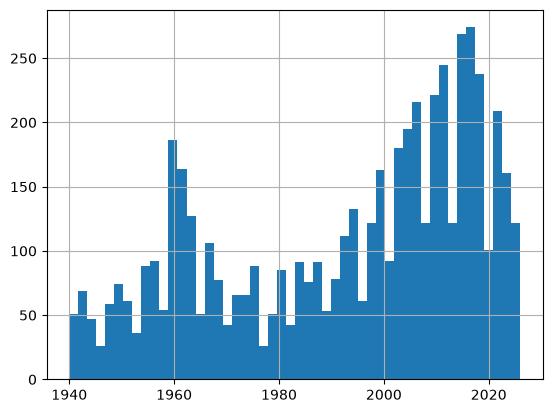

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_excel("data/GSAF5.xls")


print("df.shape:")
print(df.shape, "\n")

print("df.dtypes:")
print(df.dtypes, "\n")

df.head()

# to remove the columns that don't have actual data
df = df.loc[:, df.isnull().sum() < len(df)-2]

var = "Year"
print(df[var].unique(), "\n")

# convert Year to a numbers
df[var] = pd.to_numeric(df[var], errors="coerce")
df[var] = df[var].replace(0, np.nan) # replace 0s with nan

df["Year_nan"] = df[var].isnull()
print(df[var].describe(), "\n")
print("Total missing years:" + str(sum(df["Year_nan"])), "\n")

df = df[df[var] >= 1940] # filter by 1940 and above
print(df[var].describe(), "\n")
df[var].hist(bins=50)
# The histogram shows that recorded attacks mostly increased over time. The most increase happening from the 1990s-2010s



['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


<Axes: >

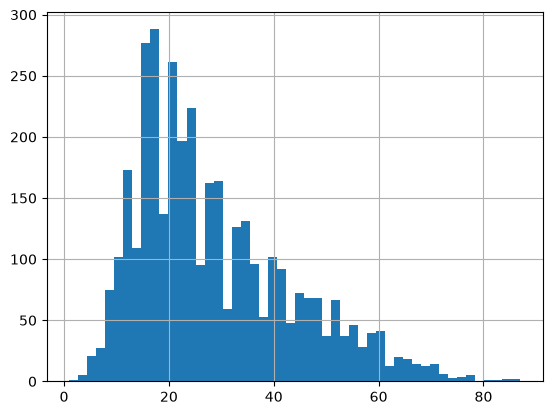

In [4]:
# age
var = "Age"
print(df[var].unique(), "\n")
df[var] = pd.to_numeric(df[var], errors="coerce") # convert age to numbers

df["Age_nan"] = df[var].isnull() # attain the missing values
print(df[var].describe(), "\n")
df[var].hist(bins=50)


In [5]:
# sex
var = "Sex"
print(df[var].unique(), "\n")
# clean up the different male and female entrys into just M and F
df[var] = df[var].replace(["M ", " M", "m"], "M")
df[var] = df[var].replace("F ", "F")
# the ones that don't make sense just make them missing for now
df[var] = df[var].replace(["M F", "?", "lli", "M x 2", "N", "."], np.nan)

df["Sex_nan"] = df[var].isnull()
proportion_male = (sum(df[var] == "M") / (len(df[var]) - sum(df["Sex_nan"])))
print("Proportion male:" + str(proportion_male))
# approximately 85.72% of victims with a known Sex value are male. there are a lot that are missing though



<StringArray>
['F', 'M', 'M ', 'M F', '?', 'F ', nan, ' M', 'm', 'lli', 'M x 2']
Length: 11, dtype: str 

Proportion male:0.8571707317073171


In [6]:
# type
var = "Type"
print(df[var].unique(), "\n")

# some entrys seems to mean the same thing but have different naming, clean those up with the replace
df[var] = df[var].replace(" Provoked", "Provoked")
df[var] = df[var].replace(["UNprovoked", "unprovoked"], "Unprovoked")

# Everything that isn't Provoked or Unprovoked, i just change to "Unknown"
df[var] = df[var].replace(["Watercraft", "Sea Disaster","Questionable", "?", "Unconfirmed", "Unverified", "Invalid", "Under investigation", "Boat"], "Unknown")
df[var] = df[var].fillna("Unknown")

proportion_unprovoked = (sum(df[var] == "Unprovoked") / len(df[var]))
print("Proportion unprovoked:" + str(proportion_unprovoked))
# approximately 74.59% of attacks since 1940 are unprovoked, however keep in mind there were entries that are considered unknown

<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'UNprovoked',          'unprovoked',           ' Provoked',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under investigation',                'Boat']
Length: 15, dtype: str 

Proportion unprovoked:0.7459236695932628


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** `4b122117253d40a1af9952e5626efa32f4eb123c`
- **AI tool and model used:** Anthropic Claude (Sonnet 5)

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

1. "I'm doing Phase 2. Go through my Phase 1 notebook and suggest revisions and
   improvements."
2. "Give me the revised Phase 2 code and the proposed changes list so I can paste them in myself. Don't touch the frozen Phase 1 cells."


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]
1. Add prose answers for the parts that explicitly require them: Q1.1 "explain
   the choices you make", Q1.2 "Is this a concern? / patterns in the
   missingness" (currently answered only in code comments), and Q2.3 "describe
   the range of values you see".
2. (Optional) Q2.4 Age: recover ~90 coerce-able entries such as "30s" / "Teen"
   by extracting leading digits before converting to numeric, instead of
   dropping them. The Phase 1 coercion already satisfies "clean the Age
   variable and make a histogram".
3. (Optional) Give each dataset its own variable name instead of reusing one
   `df`, so cells don't depend on execution order.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Written answers in markdown | Accept | Assignment explicitly asks for these. |
| 2. Age leading-digit recovery | Accept | I can add more ages to the data, which would make the answer more accurate |
| 3. Separate dataframe names | Reject| The code works with df being reused, even if execution order is now important. |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [7]:
# Your Phase 2 solution to the problem goes here.


### Written answers (Phase 2)

**Q1.1 — Price.** `Price` is stored as text. The only formatting problem is the
thousands separator that appears once a nightly price reaches $1,000 (e.g.
`"1,112"`). Removing commas and converting to numeric parses every row, so I end
up with **0 missing values**. Prices range $10–$10,000 (median $125).

**Q1.2 — subject_injury.** After coercing blanks to NaN, **9,848 / 12,925 =
76.19%** of values are missing. This is a concern: the cross-tabulation with
`force_type` shows the missingness is not random. *Less Lethal* (87 rows) and
*Maximal Restraint Technique* (170 rows) have injury outcomes recorded for **0%**
of cases, and *Chemical Irritant* for only ~11%, while other force types are far
better recorded. Injury outcomes are systematically under-reported for specific
force types, so any analysis built on this variable is biased.

**Q2.3 — Year.** Raw years include junk low values (5, 77, 1000, 1500, …) and
`0` placeholders, which I recode to NaN; valid years run up to 2026. After
filtering to Year ≥ 1940 there are 5,581 rows. The histogram shows recorded
attacks **increasing** over time, with the largest growth from the 1990s to the
2010s.

Year raw values: [2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914. 1913. 1912. 1911. 1910. 1909.
 1908. 1907. 1906. 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1897.
 1896. 1895. 1894. 1893. 1892. 1891. 1890. 1889. 1888. 1887. 1886. 1885.
 1884. 1883. 1882. 1881. 1880. 1879. 1878. 1877. 1876. 1875. 1874. 1873.
 1872. 1871. 1870. 1869. 1868. 186

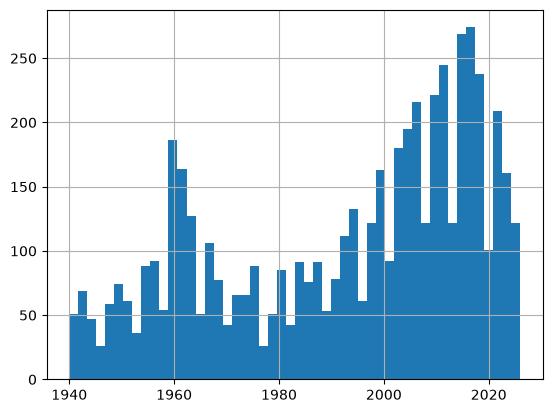

Age raw values: ['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "

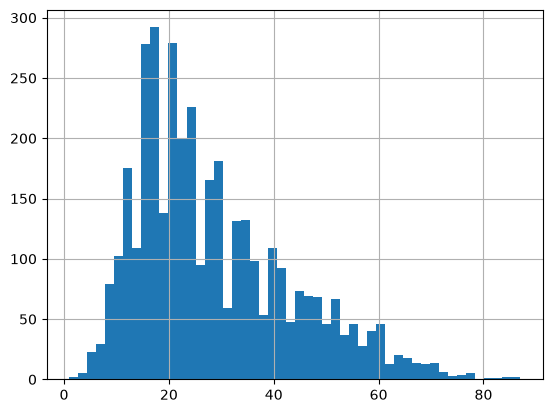

In [8]:
# suggestion 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel("data/GSAF5.xls")

# --- Q2.2  drop columns with no data ---
df = df.loc[:, df.isnull().sum() < len(df) - 2]

# --- Q2.3  clean Year, filter to attacks since 1940 ---
var = "Year"
print(var, "raw values:", df[var].unique(), "\n")
df[var] = pd.to_numeric(df[var], errors="coerce")
df[var] = df[var].replace(0, np.nan)             # 0 is a placeholder, not a real year
df["Year_nan"] = df[var].isnull()
print(df[var].describe(), "\n")
print("Total missing years:", sum(df["Year_nan"]), "\n")

df = df[df[var] >= 1940]                          # since 1940 (also drops missing-year rows)
print(df[var].describe(), "\n")
df[var].hist(bins=50)
plt.show()

# --- Q2.4  clean Age, histogram ---
var = "Age"
print(var, "raw values:", df[var].unique(), "\n")
age_str = df[var].astype("string").str.strip()
age_str = age_str.mask(age_str.str.contains("month", case=False, na=False))  # "9 months" is not 9 years
df[var] = pd.to_numeric(age_str.str.extract(r"(\d+)")[0], errors="coerce")   # recover "20s", "30+", "mid-40s"
df["Age_nan"] = df[var].isnull()
print(df[var].describe(), "\n")
df[var].hist(bins=50)
plt.show()



### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I think overall, AI did a pretty good job finding and improving the code I wrote. Its main 3 suggestions were all pretty valid. The first one was just tell me to justify some of the code I wrote in the markdown and I think it gave a good comprehensive summary of what I did in the markdown output it suggested. For the second suggestion, it gave a pretty good idea since before, i just got rid of anything that wasn't strictly numbers, but claude gave me a way to save some of the cells such as 20s. The third suggestion, though valid for making my code more robust, I felt wasn't strictly necessary so I didn't go through and implement it since my code still seems to work. I didn't notice AI making any major mistakes, maybe slightly misunderstanding instructions at times but overall it seems to have given valid criticisms to what I was trying to do. I can verify the second suggestion works because I can see that there are more total age values now.